# Horizon chromaticity: eigenmode / PCA analysis (zenith pointing)

Compares foreground chromaticity of three horizon cases (`flat`,
`quarry`, `eigsep`) for a **fixed zenith-pointing antenna**, via SVD of
the simulated zenith drift spectra, and tests how much 21-cm signal
survives projecting out the dominant beam-weighted foreground modes.

- `flat` — constant-θ cut at θ = 90°: flat ground, exactly half the
  sky blocked (2π sr). Simulated zenith-only.
- `quarry` — constant-θ cut matched to the blocked solid angle of the
  real EIGSEP horizon (θ_c ≈ 71°).
- `eigsep` — the realistic EIGSEP quarry horizon.

The analysis is done on the **ground-loss-corrected sky temperature**

$$T_{\rm sky} = \frac{T_{\rm sys} - T_{\rm rcvr} - f_{\rm gnd} T_{\rm gnd}}{1 - f_{\rm gnd}},$$

i.e. the beam-weighted average sky temperature over the visible sky
(`eigsim.correct_ground_loss`). Only the **zenith pointing**
(el=0, az=0) is used: the earlier full-rotation (1296-orientation)
analysis was dropped from the paper, and the `flat` case is simulated
for zenith only. (The previous notebook revision with the pooled
all-orientation analysis and the `nohorizon` case is in git history.)

**Inputs** (run `make_horizons.py`, `run_sims.py --case <c>` —
`--zenith-only` for `flat` — and `compute_fgnd.py` first):

- `../output/horizons.npz` — masks + ring-cut metadata
- `../output/chromaticity_<case>.npz` — noiseless `t_sys`;
  `(1, 1436, 201)` for `flat`, `(1296, 1436, 201)` for the others
  (only the zenith row is used)
- `../output/fgnd_<case>.npz` — ground fractions
- 21-cm signal models (K, MHz after conversion) from
  `~/Documents/research/eigsep/mock_analysis/notebooks/spatial_filter/models_21cm.npz`

Sections: horizon profiles → zenith extraction → sanity waterfalls →
SVD, raw vs corrected (Fig. 1) → 21-cm models → foreground filtering vs
signal survival (Fig. 2) → removal thresholds & the signal-vs-foreground
crossover in the foreground eigenbasis → full model-family spread →
a-priori GSM frequency basis & beam correction → reviewer figures
(Figs. 3-4 + alternates).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm
from pygdsm import GlobalSkyModel16

OUTPUT_DIR = Path("..") / "output"
CASES = ["flat", "quarry", "eigsep"]
COLORS = {"flat": "C0", "quarry": "C1", "eigsep": "C2"}

# 21-cm model set (file stores freqs in GHz, models in mK)
T21_FILE = (
    Path.home()
    / "Documents/research/eigsep/mock_analysis/notebooks"
    / "spatial_filter/models_21cm.npz"
)

## Horizon profiles

Altitude of the horizon vs azimuth for each case, plus the blocked-sky
summary saved by `make_horizons.py`. `flat` is the constant-altitude-0
horizon (half the sky blocked); `quarry` is the constant-altitude
horizon with the same blocked solid angle as the realistic eigsep
horizon.

In [2]:
hz = np.load(OUTPUT_DIR / "horizons.npz")
ntheta, nphi = hz["eigsep"].shape
theta_deg = np.degrees(np.linspace(0, np.pi, ntheta))
phi_deg = np.degrees(np.linspace(0, 2 * np.pi, nphi, endpoint=False))


def horizon_altitude_profile(mask):
    '''Horizon altitude (deg) vs azimuth; -90 where nothing is blocked.'''
    blocked = ~mask  # (ntheta, nphi)
    alt = np.full(nphi, -90.0)
    for j in range(nphi):
        rows = np.nonzero(blocked[:, j])[0]
        if rows.size:
            alt[j] = 90.0 - theta_deg[rows.min()]
    return alt


profiles = {c: horizon_altitude_profile(hz[c]) for c in CASES}

print(
    f"flat cut:   theta_c = {float(hz['theta_c_flat_deg']):.2f} deg "
    f"(horizon altitude {90 - float(hz['theta_c_flat_deg']):.2f} deg)"
)
print(
    f"quarry cut: theta_c = {float(hz['theta_c_deg']):.2f} deg "
    f"(horizon altitude {90 - float(hz['theta_c_deg']):.2f} deg)"
)
for c in CASES:
    om = float(hz[f"omega_blocked_{c}"])
    print(f"  {c:10s} blocked {om:7.4f} sr = {om / (4 * np.pi):5.1%} of sphere")

flat cut:   theta_c = 89.30 deg (horizon altitude 0.70 deg)
quarry cut: theta_c = 71.16 deg (horizon altitude 18.84 deg)
  flat       blocked  6.2832 sr = 50.0% of sphere
  quarry     blocked  8.2394 sr = 65.6% of sphere
  eigsep     blocked  8.2214 sr = 65.4% of sphere


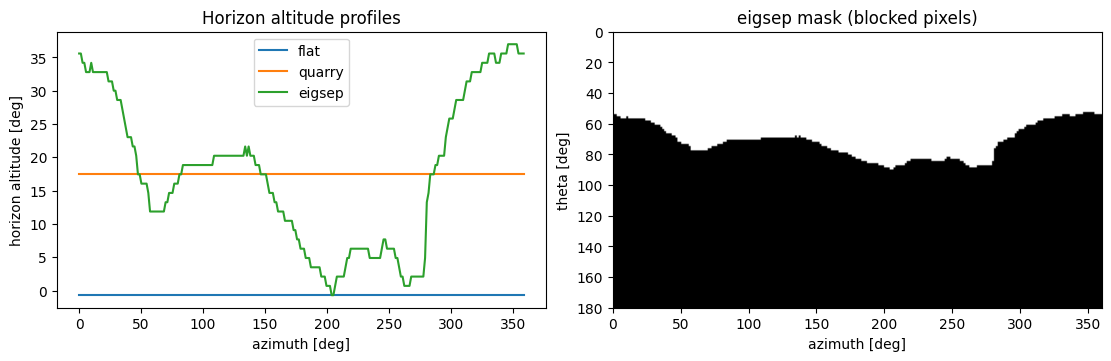

In [3]:
fig, axs = plt.subplots(1, 2, figsize=(11, 3.5), constrained_layout=True)

for c in CASES:
    axs[0].plot(phi_deg, profiles[c], color=COLORS[c], label=c)
axs[0].set_xlabel("azimuth [deg]")
axs[0].set_ylabel("horizon altitude [deg]")
axs[0].set_title("Horizon altitude profiles")
axs[0].legend()

axs[1].imshow(
    np.where(hz["eigsep"], np.nan, 1.0),
    extent=[0, 360, 180, 0],
    aspect="auto",
    cmap="copper",
)
axs[1].set_xlabel("azimuth [deg]")
axs[1].set_ylabel("theta [deg]")
axs[1].set_title("eigsep mask (blocked pixels)")
plt.show()

## Zenith extraction pass

Each full-grid `chromaticity_<case>.npz` holds a ~3 GB `t_sys` array;
only the zenith row (el=0, az=0) is kept (`flat` is zenith-only on
disk already). Per case we store the raw zenith waterfall
(1436 LSTs × 201 freqs), the ground-loss-corrected one, and the
frequency-frequency Gram matrices `G = X.T @ X` of both (eigenvectors
of `G` are the right-singular vectors of `X`; eigenvalues the squared
singular values).

The correction `t_sky = (t_sys - t_rcvr - fgnd*Tgnd) / (1 - fgnd)`
uses `fgnd` from `fgnd_<case>.npz` at the zenith orientation; the
horizon-mask SHA of the two files must match. No mean subtraction —
we want the dominant raw foreground shapes, including the overall
spectrum.

In [4]:
meta = None
extract = {}

for c in CASES:
    d = np.load(OUTPUT_DIR / f"chromaticity_{c}.npz")
    fg = np.load(OUTPUT_DIR / f"fgnd_{c}.npz")
    assert str(d["mask_sha"]) == str(fg["mask_sha"]), f"{c}: mask SHA mismatch"

    elev, az = d["elevations"], d["azimuths"]
    (zi,) = np.nonzero((elev == 0.0) & (az == 0.0))
    zen_raw = d["t_sys"][zi[0]]  # (n_times, n_freqs)

    elev_f, az_f = fg["elevations"], fg["azimuths"]
    (zfi,) = np.nonzero((elev_f == 0.0) & (az_f == 0.0))
    fgnd = fg["fgnd"][zfi[0]]  # (n_freqs,)

    t_rcvr = float(d["t_receiver"])
    t_gnd = float(d["t_ground"])
    zen_sky = (zen_raw - t_rcvr - fgnd * t_gnd) / (1.0 - fgnd)

    if meta is None:
        meta = dict(freqs=d["freqs_mhz"], times_jd=d["times_jd"])

    extract[c] = dict(
        zen_raw=zen_raw,
        zen_sky=zen_sky,
        fgnd=fgnd,
        G=zen_sky.T @ zen_sky,
        G_raw=zen_raw.T @ zen_raw,
        n_samp=zen_raw.shape[0],
    )
    del d, fg
    print(f"{c}: zenith waterfall {zen_raw.shape}, fgnd {fgnd.min():.3f}-{fgnd.max():.3f}")

freqs = meta["freqs"]
times_hr = (meta["times_jd"] - meta["times_jd"][0]) * 24.0

flat: zenith waterfall (1436, 201), fgnd 0.354-0.546


quarry: zenith waterfall (1436, 201), fgnd 0.453-0.651


eigsep: zenith waterfall (1436, 201), fgnd 0.452-0.644


## Sanity waterfalls

Raw (uncorrected) zenith system temperature vs time and frequency, per
case. These should look like normal foreground waterfalls: smooth
power-law spectra, galaxy transiting in time; the cases differ only
through what the horizon hides from the zenith-pointing beam.

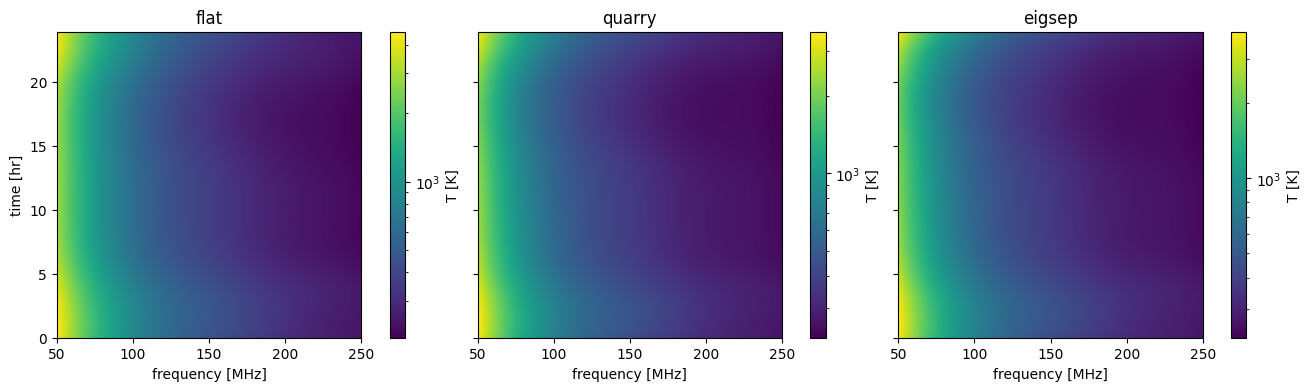

In [5]:
fig, axs = plt.subplots(
    1, len(CASES), figsize=(13, 3.8), sharex=True, sharey=True,
    constrained_layout=True,
)
for ax, c in zip(axs, CASES):
    T = extract[c]["zen_raw"]  # (n_times, n_freqs)
    im = ax.imshow(
        T,
        aspect="auto",
        origin="lower",
        extent=[freqs[0], freqs[-1], times_hr[0], times_hr[-1]],
        norm=LogNorm(),
    )
    fig.colorbar(im, ax=ax, label="T [K]")
    ax.set_title(c)
    ax.set_xlabel("frequency [MHz]")
axs[0].set_ylabel("time [hr]")
plt.show()

## SVD of the zenith waterfalls

`X = t_sky` (1436 LSTs × 201 freqs); the frequency eigenmodes and
singular values come from the eigendecomposition of the Gram matrices
computed in the extraction pass — once for the raw `t_sys` and once
for the ground-loss-corrected `t_sky`. All downstream analysis uses
the corrected `svd`; `svd_raw` is kept to quantify what the correction
changes.

(Centering note: this is an SVD of the uncentered stack — a
second-moment matrix, not a mean-subtracted covariance — so mode 1 is
essentially the mean spectrum.)

In [6]:
def compute_svd(G):
    '''Singular values / right-singular vectors of X from G = X.T @ X.'''
    U, S, Vh = np.linalg.svd(G)
    s = np.sqrt(S)
    V = Vh.T
    return dict(s=s, V=V)


svd_raw = {c: compute_svd(extract[c]["G_raw"]) for c in CASES}  # raw t_sys
svd = {c: compute_svd(extract[c]["G"]) for c in CASES}  # corrected t_sky

hdr = f"{'case':10s} {'s1/s2':>16s} {'s1/s10':>22s}"
print(hdr + "\n" + " " * 11 + f"{'raw':>7s} {'sky':>8s} {'raw':>11s} {'sky':>10s}")
for c in CASES:
    sr, ss = svd_raw[c]["s"], svd[c]["s"]
    print(
        f"{c:10s} {sr[0] / sr[1]:7.1f} {ss[0] / ss[1]:8.1f} "
        f"{sr[0] / sr[9]:11.2e} {ss[0] / ss[9]:10.2e}"
    )

case                  s1/s2                 s1/s10
               raw      sky         raw        sky
flat          37.7     90.8    4.50e+05   2.19e+05
quarry        30.1     94.7    3.91e+05   3.69e+05
eigsep        25.7     96.8    4.82e+05   3.00e+05


### Does the ground-loss correction change the singular values?

Removing the constant receiver temperature and the (weakly chromatic)
`fgnd*Tgnd` ground pickup mostly reshuffles power in the first one or
two modes; dividing by `1 - fgnd` rescales every spectrum by a
frequency-dependent factor, which can add or remove genuine chromatic
structure. The plot compares the normalized singular value spectra
before (dashed) and after (solid) correction.

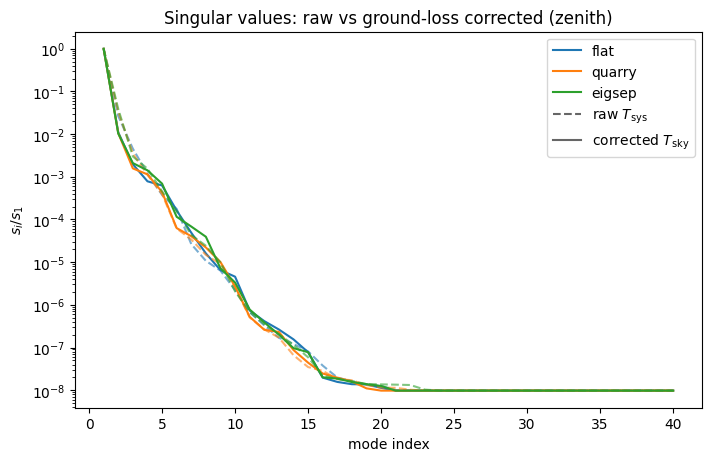

max |Δ(s_i/s_1)| / (s_i/s_1) over modes 2-10:
  flat       105.93%
  quarry     68.26%
  eigsep     73.50%


In [7]:
N_CMP = 40

fig, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
for c in CASES:
    sr, ss = svd_raw[c]["s"], svd[c]["s"]
    ax.semilogy(
        np.arange(1, N_CMP + 1),
        sr[:N_CMP] / sr[0],
        color=COLORS[c],
        ls="--",
        alpha=0.6,
    )
    ax.semilogy(
        np.arange(1, N_CMP + 1), ss[:N_CMP] / ss[0], color=COLORS[c], label=c
    )
ax.plot([], [], color="0.4", ls="--", label=r"raw $T_{\rm sys}$")
ax.plot([], [], color="0.4", label=r"corrected $T_{\rm sky}$")
ax.set_xlabel("mode index")
ax.set_ylabel(r"$s_i / s_1$")
ax.set_title("Singular values: raw vs ground-loss corrected (zenith)")
ax.legend()
plt.show()

# relative change in normalized singular values for the first 10 modes
print("max |Δ(s_i/s_1)| / (s_i/s_1) over modes 2-10:")
for c in CASES:
    sr, ss = svd_raw[c]["s"], svd[c]["s"]
    rel = np.abs(ss[1:10] / ss[0] - sr[1:10] / sr[0]) / (sr[1:10] / sr[0])
    print(f"  {c:10s} {rel.max():.2%}")

### Figure 1: singular value spectra

Ground-loss-corrected zenith `t_sky`. Steeper fall-off = less chromatic
= fewer modes needed to describe the foregrounds. Right panel shows the
first three frequency eigenmodes per case.

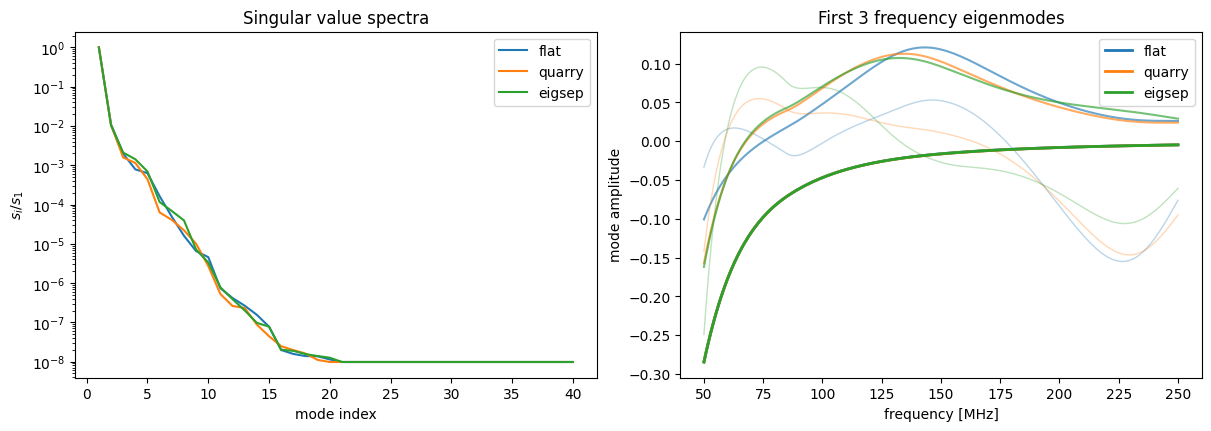

In [8]:
N_SHOW = 40

fig, axs = plt.subplots(1, 2, figsize=(12, 4.2), constrained_layout=True)

for c in CASES:
    s = svd[c]["s"]
    axs[0].semilogy(
        np.arange(1, N_SHOW + 1), s[:N_SHOW] / s[0], color=COLORS[c], label=c
    )
axs[0].set_xlabel("mode index")
axs[0].set_ylabel(r"$s_i / s_1$")
axs[0].set_title("Singular value spectra")
axs[0].legend()

for c in CASES:
    V = svd[c]["V"]
    for m in range(3):
        axs[1].plot(
            freqs,
            V[:, m],
            color=COLORS[c],
            alpha=1.0 - 0.35 * m,
            lw=2.0 - 0.5 * m,
            label=c if m == 0 else None,
        )
axs[1].set_xlabel("frequency [MHz]")
axs[1].set_ylabel("mode amplitude")
axs[1].set_title("First 3 frequency eigenmodes")
axs[1].legend()
plt.show()

fig.savefig("fig1_singular_values.pdf", bbox_inches="tight")

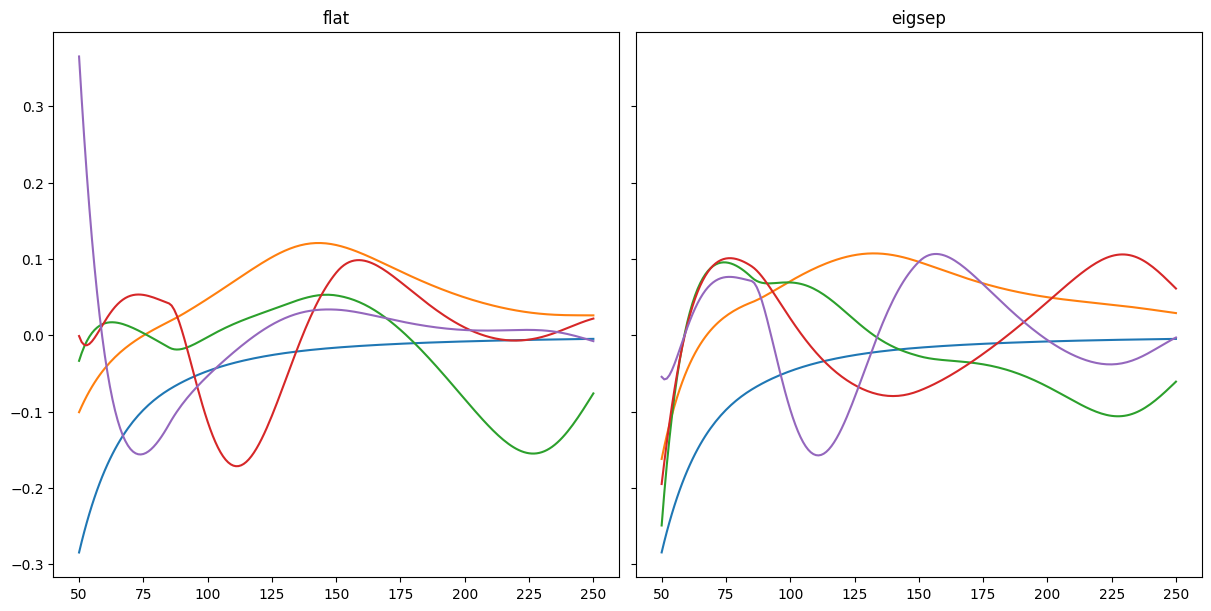

In [9]:
fig, axs = plt.subplots(figsize=(12, 6), constrained_layout=True, ncols=2, sharex=True, sharey=True)
i = 0
for c in CASES:
    if c == "quarry": continue
    ax = axs[i]
    V = svd[c]["V"]
    for m in range(5):
        ax.plot(freqs, V[:, m])
    ax.set_title(c)
    i += 1
plt.show()

## 21-cm signal models

The file stores frequencies in GHz and brightness temperatures in mK;
convert to MHz / K and interpolate onto the simulation frequency grid
(the model grid ends at 249 MHz; the last simulated channel at 250 MHz
takes the 249 MHz endpoint value, negligible where the signal is ~0).
Nominal model = the family member with absorption-trough depth closest
to 150 mK — a deep model (the family median is only ~60 mK), closer to
the amplitudes we actually hope to detect. We also build signal
eigenmodes from the model set itself.

In [10]:
t21_d = np.load(T21_FILE)
freqs21 = t21_d["freqs"] * 1e3  # GHz -> MHz
models21 = t21_d["models"] / 1e3  # mK -> K

assert 40 < freqs21[0] < 60 and 200 < freqs21[-1] < 260, "frequency units?"
assert -0.6 < models21.min() < -0.02, "temperature units?"
print(
    f"{models21.shape[0]} models, {freqs21[0]:.0f}-{freqs21[-1]:.0f} MHz, "
    f"trough depths {models21.min(axis=1).min() * 1e3:.0f} to "
    f"{models21.min(axis=1).max() * 1e3:.0f} mK"
)

# interpolate onto the simulation grid
t21 = np.array([np.interp(freqs, freqs21, m) for m in models21])  # (n_models, n_freqs) [K]

depth = t21.min(axis=1)
NOMINAL_DEPTH_K = -0.150  # target trough depth for the nominal model
nominal_idx = int(np.argmin(np.abs(depth - NOMINAL_DEPTH_K)))
t21_nom = t21[nominal_idx]
print(
    f"nominal model: index {nominal_idx}, trough depth "
    f"{depth[nominal_idx] * 1e3:.0f} mK at "
    f"{freqs[int(np.argmin(t21_nom))]:.0f} MHz"
)

# signal eigenmodes from the model family
_, s21, Vt21 = np.linalg.svd(t21, full_matrices=False)

1135 models, 50-249 MHz, trough depths -256 to -3 mK
nominal model: index 893, trough depth -150 mK at 96 MHz


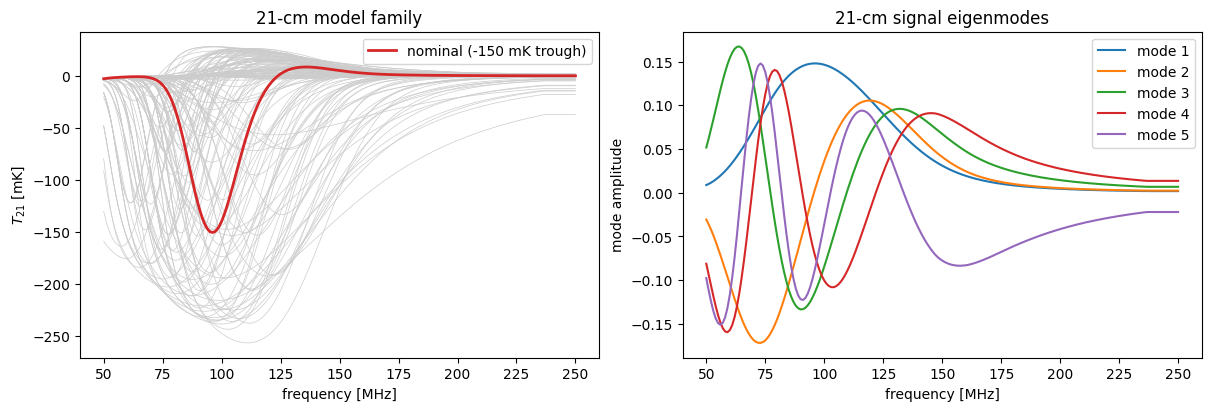

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

axs[0].plot(freqs, t21[:: max(1, len(t21) // 150)].T * 1e3, color="0.8", lw=0.5)
axs[0].plot(
    freqs,
    t21_nom * 1e3,
    color="C3",
    lw=2,
    label=f"nominal ({depth[nominal_idx] * 1e3:.0f} mK trough)",
)
axs[0].set_xlabel("frequency [MHz]")
axs[0].set_ylabel(r"$T_{21}$ [mK]")
axs[0].set_title("21-cm model family")
axs[0].legend()

for m in range(5):
    axs[1].plot(freqs, Vt21[m], label=f"mode {m + 1}")
axs[1].set_xlabel("frequency [MHz]")
axs[1].set_ylabel("mode amplitude")
axs[1].set_title("21-cm signal eigenmodes")
axs[1].legend()
plt.show()

### Figure 2: foreground filtering vs 21-cm signal survival

Project out the leading `N` foreground frequency modes of each horizon
case from (a) the data — residual foreground RMS follows from the
discarded singular values — and (b) the 21-cm models.

- **Left:** foreground residual RMS per sample-channel after removing
  `N` modes, `sqrt(sum_{i>N} s_i^2 / (n_samples * n_freqs))`.
- **Right:** fraction of the 21-cm signal norm surviving the same
  projection, for the nominal model (line) and the 16-84% range over
  the full model family (band).

The question: for a fixed foreground suppression (say residual below a
few mK), how much 21-cm signal does each horizon cost?

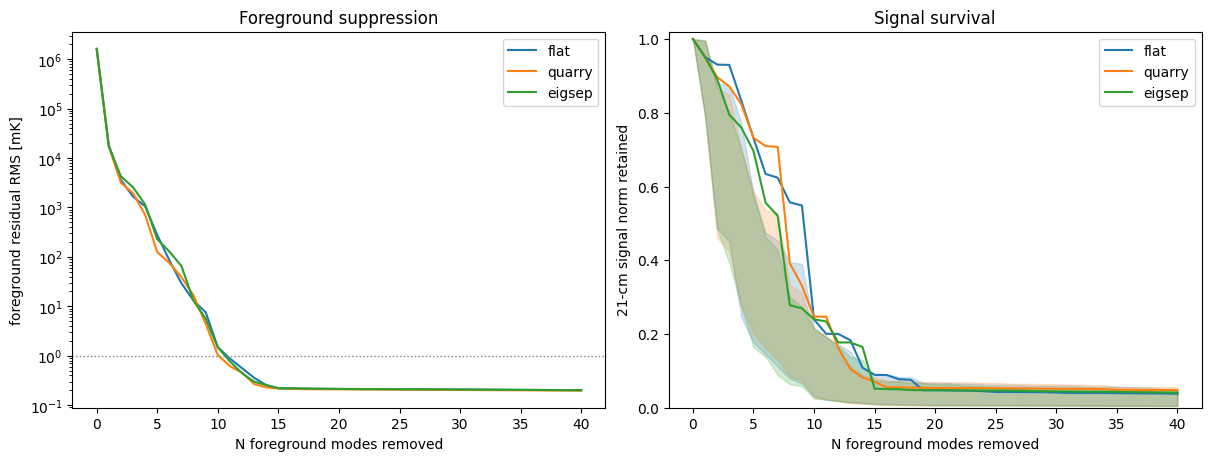

In [12]:
N_MAX = 40
n_modes = np.arange(N_MAX + 1)

fig, axs = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

norms_all = np.linalg.norm(t21, axis=1)
norm_nom = np.linalg.norm(t21_nom)
summary = {}

for c in CASES:
    s, V = svd[c]["s"], svd[c]["V"]
    n_total = extract[c]["n_samp"] * len(freqs)

    tail_power = np.concatenate([np.cumsum((s**2)[::-1])[::-1], [0.0]])
    fg_rms = np.sqrt(tail_power[n_modes] / n_total)  # [K]

    surv_nom = np.empty(len(n_modes))
    surv_lo = np.empty(len(n_modes))
    surv_hi = np.empty(len(n_modes))
    for N in n_modes:
        VN = V[:, :N]
        r_nom = t21_nom - VN @ (VN.T @ t21_nom)
        r_all = t21 - (t21 @ VN) @ VN.T
        surv_nom[N] = np.linalg.norm(r_nom) / norm_nom
        frac = np.linalg.norm(r_all, axis=1) / norms_all
        surv_lo[N], surv_hi[N] = np.percentile(frac, [16, 84])

    axs[0].semilogy(n_modes, fg_rms * 1e3, color=COLORS[c], label=c)
    axs[1].plot(n_modes, surv_nom, color=COLORS[c], label=c)
    axs[1].fill_between(n_modes, surv_lo, surv_hi, color=COLORS[c], alpha=0.2)
    summary[c] = dict(fg_rms=fg_rms, surv_nom=surv_nom)

axs[0].axhline(1.0, color="0.5", ls=":", lw=1)  # 1 mK reference
axs[0].set_xlabel("N foreground modes removed")
axs[0].set_ylabel("foreground residual RMS [mK]")
axs[0].set_title("Foreground suppression")
axs[0].legend()

axs[1].set_xlabel("N foreground modes removed")
axs[1].set_ylabel("21-cm signal norm retained")
axs[1].set_ylim(0, 1.02)
axs[1].set_title("Signal survival")
axs[1].legend()
plt.show()

fig.savefig("fig2_filtering.pdf", bbox_inches="tight")

In [13]:
# Killer numbers: modes needed to push foregrounds below 1 mK RMS,
# and the 21-cm signal surviving at that point.
print(f"{'case':12s} {'N (fg < 1 mK)':>14s} {'signal retained':>16s}")
for c in CASES:
    fg_rms, surv = summary[c]["fg_rms"], summary[c]["surv_nom"]
    below = np.nonzero(fg_rms * 1e3 < 1.0)[0]
    if below.size:
        N = int(below[0])
        print(f"{c:12s} {N:14d} {surv[N]:15.1%}")
    else:
        print(f"{c:12s} {'> ' + str(N_MAX):>14s} {'-':>16s}")

case          N (fg < 1 mK)  signal retained
flat                     11           20.0%
quarry                   11           24.7%
eigsep                   11           23.4%


## Foreground removal thresholds and the signal-vs-foreground crossover

The 1 mK target above is stricter than any realistic noise floor. Two
relaxations:

1. **Threshold sweep** — repeat the killer numbers at residual-RMS
   thresholds of 1–50 mK, plus the full trade-off curve of signal
   retained vs foreground residual (parametric in the number of
   removed modes `N`, so the same curve answers any threshold).
2. **Threshold-free criterion** (next subsection) — project the 21-cm
   signal onto each case's foreground eigenmodes and find where the
   signal content exceeds the foreground content, mode by mode and in
   the cumulative tail. No arbitrary mK target: the crossover is where
   the cleaned data hold more signal than foreground.

Caveat: the foreground amplitudes are per single simulated spectrum
(one LST). Averaging over times in a real pipeline suppresses noise
but not the (deterministic) foreground modes, so these numbers compare
horizon cases; they are not absolute detectability forecasts.

case         |    1 mK: N, sig |    5 mK: N, sig |   10 mK: N, sig |   25 mK: N, sig |   50 mK: N, sig
flat         |    11,  20.0% |    10,  23.9% |     9,  54.8% |     8,  55.7% |     7,  62.4%
quarry       |    11,  24.7% |     9,  33.1% |     9,  33.1% |     8,  39.2% |     7,  70.8%
eigsep       |    11,  23.4% |    10,  24.0% |     9,  26.9% |     8,  27.8% |     8,  27.8%


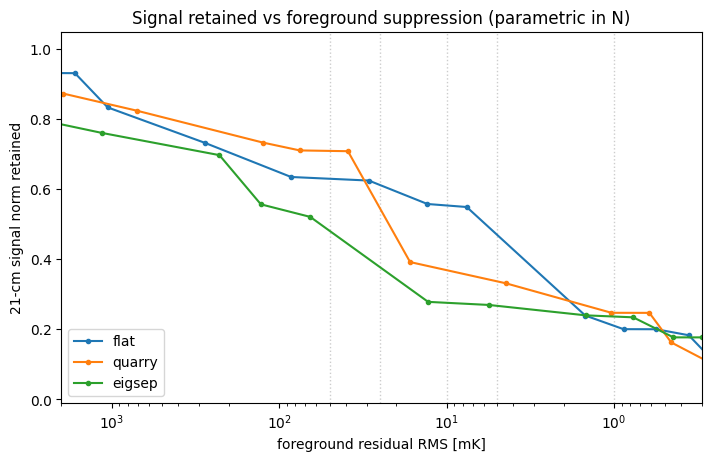

In [14]:
THRESHOLDS_MK = [1.0, 5.0, 10.0, 25.0, 50.0]

print(f"{'case':12s}" + "".join(f" | {t:>4.0f} mK: N, sig" for t in THRESHOLDS_MK))
for c in CASES:
    fg_rms, surv = summary[c]["fg_rms"], summary[c]["surv_nom"]
    cells = []
    for thr in THRESHOLDS_MK:
        N = int(np.nonzero(fg_rms * 1e3 < thr)[0][0])
        cells.append(f" | {N:5d}, {surv[N]:6.1%}")
    print(f"{c:12s}" + "".join(cells))

fig, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
for c in CASES:
    fg_rms, surv = summary[c]["fg_rms"], summary[c]["surv_nom"]
    ax.semilogx(fg_rms * 1e3, surv, color=COLORS[c], marker=".", label=c)
for thr in THRESHOLDS_MK:
    ax.axvline(thr, color="0.8", ls=":", lw=1, zorder=0)
ax.set_xlim(2e3, 0.3)  # more aggressive cleaning to the right
ax.set_xlabel("foreground residual RMS [mK]")
ax.set_ylabel("21-cm signal norm retained")
ax.set_title("Signal retained vs foreground suppression (parametric in N)")
ax.legend()
plt.show()

### Signal vs foreground in the foreground eigenbasis

Decompose both the data and the signal in the foreground eigenbasis
$\{v_i\}$ of each case:

- **foreground**: the typical (RMS over LSTs) per-channel amplitude
  of mode $i$ in a single spectrum is $s_i / \sqrt{n_{\rm samp}\,n_\nu}$;
- **signal**: per-channel amplitude $|a_i| / \sqrt{n_\nu}$ with
  $a_i = v_i^\top T_{21}$ (nominal model; band = 16–84% of the family).

**Left:** per-mode amplitudes. Where the dashed signal curve rises
above the solid foreground curve, that mode carries more signal than
foreground. **Right:** cumulative tails after removing the first $N$
modes — the ratio (signal tail)/(foreground tail) crosses 1 at the
point where the cleaned spectra contain literally more 21-cm signal
than residual foreground.

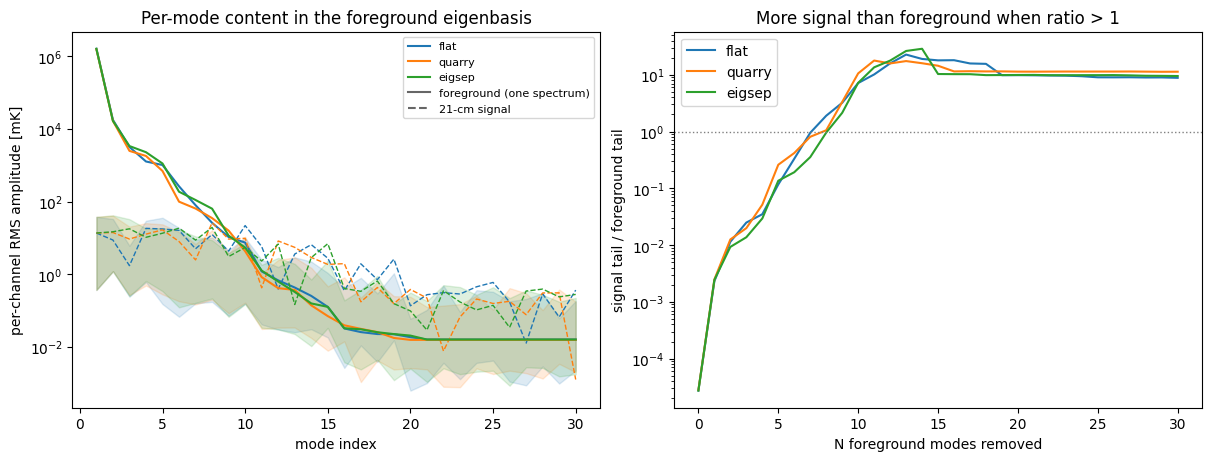

case          1st mode sig>fg  N (tail sig>fg)  fg resid [mK]  signal retained
flat                       10                8          13.03           55.7%
quarry                     10                8          16.52           39.2%
eigsep                     10                9           5.60           26.9%


In [15]:
K_SHOW = 30
sqrt_nf = np.sqrt(len(freqs))

fig, axs = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

cross = {}
for c in CASES:
    s, V = svd[c]["s"], svd[c]["V"]
    n_samp = extract[c]["n_samp"]

    # per-channel RMS amplitude of mode i: foreground (typical single
    # spectrum) and 21-cm signal (nominal + 16-84% of the model family)
    fg_mode = s / np.sqrt(n_samp) / sqrt_nf * 1e3  # [mK]
    a_nom = V.T @ t21_nom
    sig_mode = np.abs(a_nom) / sqrt_nf * 1e3  # [mK]
    a_fam = np.abs(t21 @ V)  # (n_models, n_freqs)
    sig_lo, sig_hi = np.percentile(a_fam, [16, 84], axis=0) / sqrt_nf * 1e3

    m = np.arange(1, K_SHOW + 1)
    axs[0].semilogy(m, fg_mode[:K_SHOW], color=COLORS[c], label=c)
    axs[0].semilogy(m, sig_mode[:K_SHOW], color=COLORS[c], ls="--", lw=1)
    axs[0].fill_between(
        m, sig_lo[:K_SHOW], sig_hi[:K_SHOW], color=COLORS[c], alpha=0.15
    )

    # cumulative tails after removing the first N modes
    fg_tail = (
        np.sqrt(
            np.concatenate([np.cumsum((s**2)[::-1])[::-1], [0.0]]) / n_samp
        )
        / sqrt_nf
        * 1e3
    )
    sig_tail = (
        np.sqrt(np.concatenate([np.cumsum((a_nom**2)[::-1])[::-1], [0.0]]))
        / sqrt_nf
        * 1e3
    )
    with np.errstate(invalid="ignore", divide="ignore"):
        ratio = sig_tail / fg_tail
    N_arr = np.arange(len(ratio))
    axs[1].semilogy(
        N_arr[: K_SHOW + 1], ratio[: K_SHOW + 1], color=COLORS[c], label=c
    )

    mode_hits = np.nonzero(sig_mode > fg_mode)[0]
    tail_hits = np.nonzero(ratio[:-1] > 1.0)[0]
    Nx_mode = int(mode_hits[0]) + 1 if mode_hits.size else None
    Nx_tail = int(tail_hits[0]) if tail_hits.size else None
    cross[c] = dict(
        Nx_mode=Nx_mode,
        Nx_tail=Nx_tail,
        fg_resid=fg_tail[Nx_tail] if Nx_tail is not None else np.nan,
        retained=sig_tail[Nx_tail] / sig_tail[0]
        if Nx_tail is not None
        else np.nan,
    )

axs[0].plot([], [], color="0.4", label="foreground (one spectrum)")
axs[0].plot([], [], color="0.4", ls="--", label="21-cm signal")
axs[0].set_xlabel("mode index")
axs[0].set_ylabel("per-channel RMS amplitude [mK]")
axs[0].set_title("Per-mode content in the foreground eigenbasis")
axs[0].legend(fontsize=8)

axs[1].axhline(1.0, color="0.5", ls=":", lw=1)
axs[1].set_xlabel("N foreground modes removed")
axs[1].set_ylabel("signal tail / foreground tail")
axs[1].set_title("More signal than foreground when ratio > 1")
axs[1].legend()
plt.show()

print(
    f"{'case':12s} {'1st mode sig>fg':>16s} {'N (tail sig>fg)':>16s} "
    f"{'fg resid [mK]':>14s} {'signal retained':>16s}"
)
for c in CASES:
    x = cross[c]
    print(
        f"{c:12s} {x['Nx_mode']:16d} {x['Nx_tail']:16d} "
        f"{x['fg_resid']:14.2f} {x['retained']:15.1%}"
    )

### Family spread in the foreground eigenbasis

The bands above compress the 1135-model family into two quantiles. Here
**every** model is projected onto each case's foreground eigenmodes
$|v_i^\top T_{21}| / \sqrt{n_\nu}$, colored by its absorption-trough
depth, with the single-spectrum foreground amplitude (black) and the
nominal model (red dashed) overlaid. This shows directly which part of
the astrophysical model space clears the foreground floor, and at which
mode index.

Below the figure: the distribution over the family of the tail
crossover $N$ (first $N$ where the cumulative signal tail exceeds the
foreground tail), to check how robust the crossover numbers are to the
choice of 21-cm model.

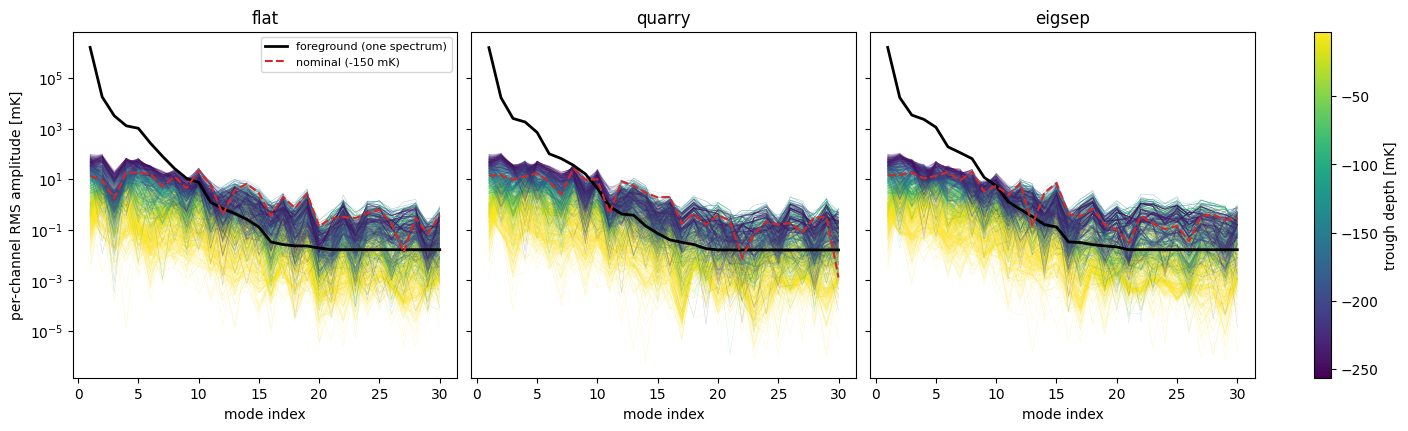

case            N crossover (tail sig>fg) over the family
                  min      16%      50%      84%      max  never
flat                7        8       10       13      200    236
quarry              7        9        9       13      200    182
eigsep              8        9       10       12      200    266


In [16]:
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

K_FAM = 30
depth_mk = depth * 1e3
cnorm = Normalize(vmin=depth_mk.min(), vmax=depth_mk.max())
cmap = plt.get_cmap("viridis")
# draw shallow models first so the deep ones end up on top
draw_order = np.argsort(depth_mk)[::-1]

fig, axs = plt.subplots(
    1, len(CASES), figsize=(14, 4.2), sharey=True, constrained_layout=True
)
m = np.arange(1, K_FAM + 1)
for ax, c in zip(axs, CASES):
    s, V = svd[c]["s"], svd[c]["V"]
    n_samp = extract[c]["n_samp"]
    a_fam = np.abs(t21 @ V) / sqrt_nf * 1e3  # (n_models, n_freqs) [mK]
    for i in draw_order:
        ax.semilogy(
            m,
            a_fam[i, :K_FAM],
            color=cmap(cnorm(depth_mk[i])),
            lw=0.3,
            alpha=0.25,
        )
    fg_mode = s / np.sqrt(n_samp) / sqrt_nf * 1e3  # [mK]
    ax.semilogy(
        m, fg_mode[:K_FAM], color="k", lw=2, label="foreground (one spectrum)"
    )
    ax.semilogy(
        m,
        np.abs(V.T @ t21_nom)[:K_FAM] / sqrt_nf * 1e3,
        color="C3",
        ls="--",
        lw=1.5,
        label=f"nominal ({depth[nominal_idx] * 1e3:.0f} mK)",
    )
    ax.set_title(c)
    ax.set_xlabel("mode index")
axs[0].set_ylabel("per-channel RMS amplitude [mK]")
axs[0].legend(fontsize=8)
fig.colorbar(
    ScalarMappable(norm=cnorm, cmap=cmap), ax=axs, label="trough depth [mK]"
)
plt.show()

# tail-crossover N for every model in the family
print(
    f"{'case':12s} {'N crossover (tail sig>fg) over the family':>44s}\n"
    f"{'':12s} {'min':>8s} {'16%':>8s} {'50%':>8s} {'84%':>8s} {'max':>8s} "
    f"{'never':>6s}"
)
for c in CASES:
    s, V = svd[c]["s"], svd[c]["V"]
    n_samp = extract[c]["n_samp"]
    fg_tail = np.sqrt(
        np.concatenate([np.cumsum((s**2)[::-1])[::-1], [0.0]]) / n_samp
    )
    A = t21 @ V  # (n_models, n_freqs)
    sig_tail = np.sqrt(
        np.concatenate(
            [np.cumsum((A**2)[:, ::-1], axis=1)[:, ::-1],
             np.zeros((len(t21), 1))],
            axis=1,
        )
    )
    with np.errstate(invalid="ignore", divide="ignore"):
        above = sig_tail[:, :-1] > fg_tail[:-1]
    crossed = above.any(axis=1)
    n_x = np.argmax(above, axis=1)[crossed]
    pct = np.percentile(n_x, [0, 16, 50, 84, 100]).astype(int)
    print(
        f"{c:12s} {pct[0]:8d} {pct[1]:8d} {pct[2]:8d} {pct[3]:8d} "
        f"{pct[4]:8d} {(~crossed).sum():6d}"
    )

## Projecting out GSM frequency modes directly (sky-only basis)

GSM16 is built from six spectral components (plus the CMB monopole in
our configuration), so every pixel spectrum — and any **achromatic**
beam-weighted average of pixel spectra — lives in a ~7-dimensional
frequency subspace. That subspace is known *a priori* (no data needed)
and is signal-blind by construction.

With a chromatic beam and a horizon, the observed spectra leak out of
this subspace: the beam reweights the sky differently at every
frequency, multiplying each component spectrum by a direction- and
frequency-dependent gain. **The residual after projecting out the raw
GSM frequency modes is therefore a direct measure of beam + horizon
chromaticity** — the part of the spectrum that no sky spectral model
can absorb.

We regenerate the same sky cube as `run_sims.py` (GSM16, settings read
back from the npz metadata), SVD it over pixels (healpix pixels are
equal-area, so plain SVD = solid-angle weighting), and project the
leading $K$ sky modes out of the zenith Gram matrices and the 21-cm
models. The dotted curves repeat Fig. 2's own-eigenbasis cleaning for
reference: the own basis keeps cutting, while the sky-only basis hits
a chromaticity floor.

sky singular values s_i/s_1: [1.0e+00 3.8e-02 6.1e-03 6.0e-04 2.6e-04 2.6e-04 2.4e-04 2.3e-04 2.2e-04
 2.0e-04]


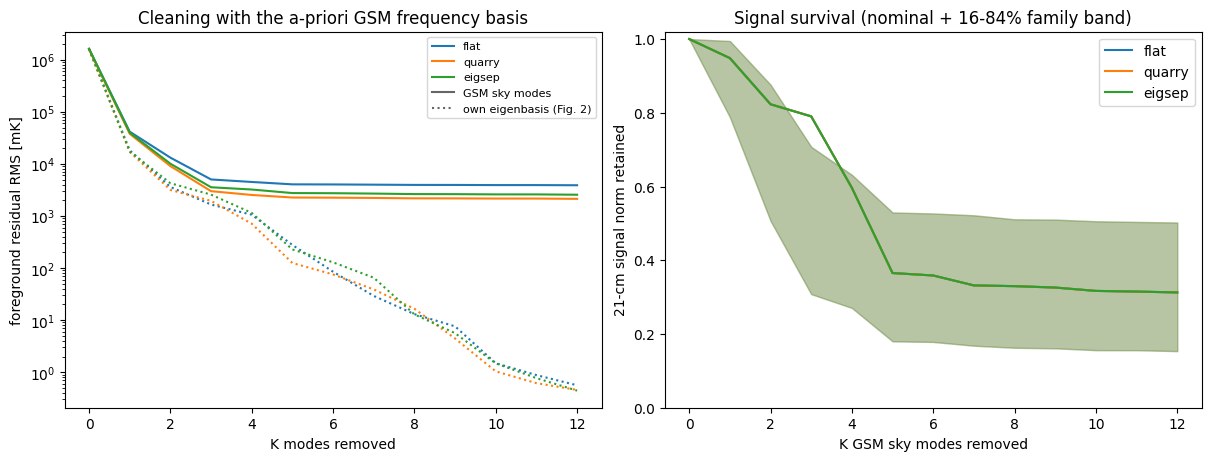

after removing 7 GSM sky modes:
case          fg resid [mK]  signal retained
flat                 3992.6           33.2%
quarry               2219.4           33.2%
eigsep               2691.5           33.2%


In [17]:
# rebuild the exact sky cube used by run_sims.py (npz members load lazily,
# so this does not touch the t_sys arrays)
d_meta = np.load(OUTPUT_DIR / "chromaticity_eigsep.npz")
assert str(d_meta["sky_model"]) == "gsm16"
gsm = GlobalSkyModel16(
    freq_unit="MHz",
    data_unit="TRJ",
    resolution=str(d_meta["sky_resolution"]),
    include_cmb=bool(d_meta["sky_include_cmb"]),
)
sky_map = np.asarray(gsm.generate(freqs))  # (n_freqs, n_pix), galactic

sky_svd = compute_svd(sky_map @ sky_map.T)  # frequency modes of the sky alone
s_sky, U_sky = sky_svd["s"], sky_svd["V"]
print(
    "sky singular values s_i/s_1:",
    np.array2string(s_sky[:10] / s_sky[0], precision=1, floatmode="maxprec"),
)

K_GSM = 12
ks = np.arange(K_GSM + 1)
gsm_summary = {}

fig, axs = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
for c in CASES:
    G = extract[c]["G"]
    n_total = extract[c]["n_samp"] * len(freqs)

    # residual data power after projecting out the first K sky modes:
    # tr(G) - sum_{k<K} u_k^T G u_k  (U_sky columns are orthonormal)
    quad = np.sum(U_sky * (G @ U_sky), axis=0)
    resid_power = np.trace(G) - np.concatenate([[0.0], np.cumsum(quad)])
    fg_rms = np.sqrt(np.clip(resid_power[: K_GSM + 1], 0.0, None) / n_total)

    a_nom = U_sky.T @ t21_nom
    sig_resid = norm_nom**2 - np.concatenate([[0.0], np.cumsum(a_nom**2)])
    surv = np.sqrt(np.clip(sig_resid[: K_GSM + 1], 0.0, None)) / norm_nom

    A = t21 @ U_sky  # (n_models, n_freqs)
    fam_resid = norms_all[:, None] ** 2 - np.concatenate(
        [np.zeros((len(t21), 1)), np.cumsum(A**2, axis=1)], axis=1
    )
    fam_surv = (
        np.sqrt(np.clip(fam_resid[:, : K_GSM + 1], 0.0, None))
        / norms_all[:, None]
    )
    lo, hi = np.percentile(fam_surv, [16, 84], axis=0)

    axs[0].semilogy(ks, fg_rms * 1e3, color=COLORS[c], label=c)
    axs[0].semilogy(
        ks, summary[c]["fg_rms"][: K_GSM + 1] * 1e3, color=COLORS[c], ls=":"
    )
    axs[1].plot(ks, surv, color=COLORS[c], label=c)
    axs[1].fill_between(ks, lo, hi, color=COLORS[c], alpha=0.2)
    gsm_summary[c] = dict(fg_rms=fg_rms, surv=surv)

axs[0].plot([], [], color="0.4", label="GSM sky modes")
axs[0].plot([], [], color="0.4", ls=":", label="own eigenbasis (Fig. 2)")
axs[0].set_xlabel("K modes removed")
axs[0].set_ylabel("foreground residual RMS [mK]")
axs[0].set_title("Cleaning with the a-priori GSM frequency basis")
axs[0].legend(fontsize=8)

axs[1].set_xlabel("K GSM sky modes removed")
axs[1].set_ylabel("21-cm signal norm retained")
axs[1].set_ylim(0, 1.02)
axs[1].set_title("Signal survival (nominal + 16-84% family band)")
axs[1].legend()
plt.show()

K_REF = 7  # sky basis is effectively exhausted here
print(
    f"after removing {K_REF} GSM sky modes:\n"
    f"{'case':12s} {'fg resid [mK]':>14s} {'signal retained':>16s}"
)
for c in CASES:
    g = gsm_summary[c]
    print(f"{c:12s} {g['fg_rms'][K_REF] * 1e3:14.1f} {g['surv'][K_REF]:15.1%}")

### How would we correct the beam?

GSM16 is linear in its spatial components: $T(\nu, \hat n) = \sum_k
f_k(\nu)\, M_k(\hat n)$. With a perfectly known beam $B(\nu, \hat n)$,
forward-model each component map through the instrument (the same
machinery as `run_sims.py`, one frequency-independent map at a time).
For every LST that yields the beam-distorted templates

$$h_k(\nu;\, t) = f_k(\nu)\, \frac{\int B(\nu, \hat n)\,
M_k(\hat n)\, d\Omega}{\int B(\nu, \hat n)\, d\Omega},$$

and the observed foreground spectrum is *exactly* $\sum_k h_k$. So
projecting out the (at most ~7) templates per pointing removes the
foreground completely while staying signal-blind — the basis is built
from the sky model and the beam, never from data containing the
signal. The cost of perfect cleaning is only the part of $T_{21}$
lying in that low-dimensional subspace.

Two caveats worth one sentence each in the paper:

1. In our closed simulation world the sky **is** GSM16, so
   beam-corrected projection is exact by construction; the realistic
   limit is set by GSM (and beam-model) inaccuracy, not by the method.
2. Producing the templates costs one `run_sims.py`-scale simulation
   per component (~6-7 runs) — feasible, same bucket as the
   $\theta = 90°$ flat-ground case (now simulated here as `flat`).

The zenith SVD basis used in the main analysis is the empirical,
beam-agnostic stand-in for exactly this construction: it discovers the
beam-distorted sky modes from the data itself, at the price of needing
more modes and of (in real data) absorbing some signal.

## Reviewer figures: zenith-pointing antenna, horizon comparison

The fixed zenith-pointing antenna is the configuration of interest;
two versions of the figure, both built on each case's zenith
beam-weighted foreground eigenbasis:

- **Version 1 (`fig3`)** — per-mode content: the foreground per-channel
  amplitude (solid) vs the 21-cm model family projected onto the same
  basis (16–84% band, nominal 150 mK model dashed). Where the band
  clears the solid curve, those modes carry more signal than
  foreground. The three colors compare horizon profiles.
- **Version 2 (`fig4`)** — what is left in frequency space after
  removing just enough modes that the residual foreground drops below
  the signal (the tail crossover $N_\times$ per case): residual
  foreground RMS per channel (left) and the filtered nominal 21-cm
  signal vs the unfiltered one (right).

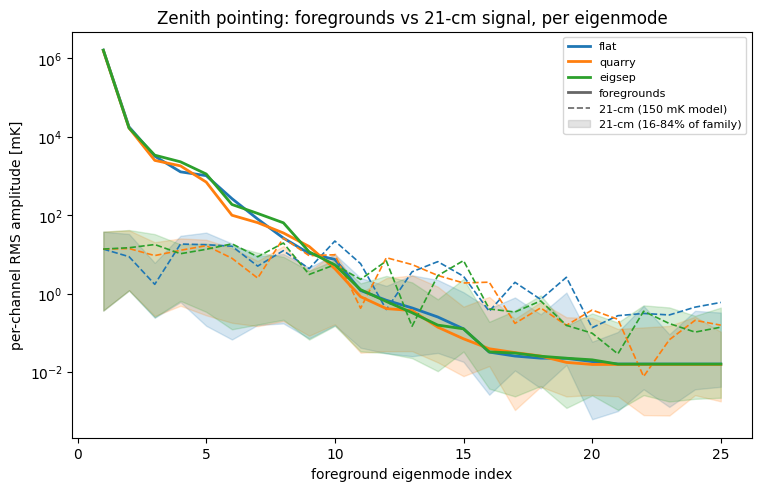

In [18]:
# Version 1: per-mode foreground vs 21-cm family, zenith basis
K_REV = 25
m = np.arange(1, K_REV + 1)

fig, ax = plt.subplots(figsize=(7.5, 4.8), constrained_layout=True)
for c in CASES:
    s, V = svd[c]["s"], svd[c]["V"]
    n_samp = extract[c]["n_samp"]
    fg_mode = s / np.sqrt(n_samp) / sqrt_nf * 1e3  # [mK]
    a_fam = np.abs(t21 @ V) / sqrt_nf * 1e3  # (n_models, n_freqs) [mK]
    lo, hi = np.percentile(a_fam, [16, 84], axis=0)
    ax.semilogy(m, fg_mode[:K_REV], color=COLORS[c], lw=2, label=c)
    ax.fill_between(m, lo[:K_REV], hi[:K_REV], color=COLORS[c], alpha=0.18)
    ax.semilogy(
        m,
        np.abs(V.T @ t21_nom)[:K_REV] / sqrt_nf * 1e3,
        color=COLORS[c],
        ls="--",
        lw=1.2,
    )
ax.plot([], [], color="0.4", lw=2, label="foregrounds")
ax.plot([], [], color="0.4", ls="--", lw=1.2, label="21-cm (150 mK model)")
ax.fill_between([], [], [], color="0.4", alpha=0.18, label="21-cm (16-84% of family)")
ax.set_xlabel("foreground eigenmode index")
ax.set_ylabel("per-channel RMS amplitude [mK]")
ax.set_title("Zenith pointing: foregrounds vs 21-cm signal, per eigenmode")
ax.legend(fontsize=8)
plt.show()

fig.savefig("fig3_zenith_eigenbasis.pdf", bbox_inches="tight")

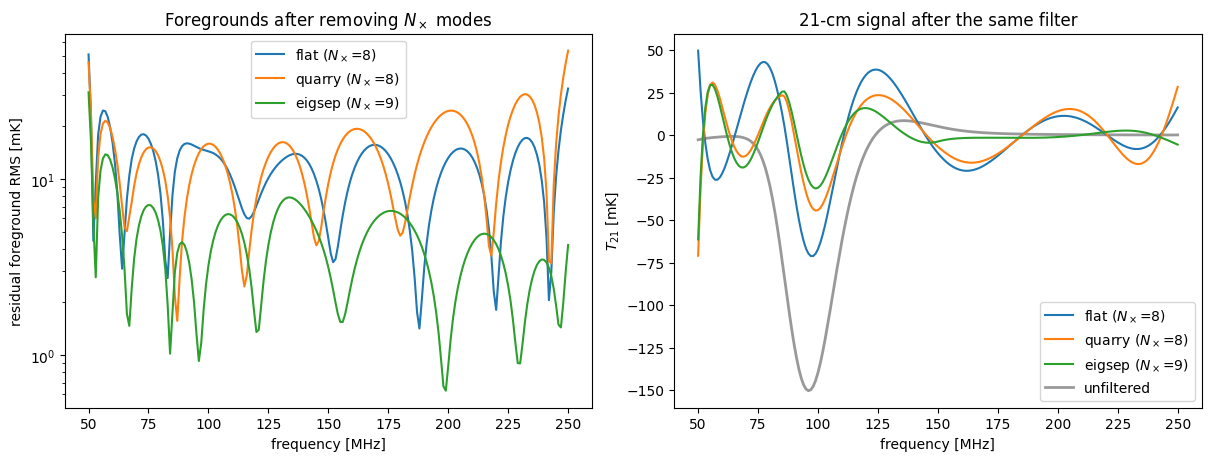

In [19]:
# Version 2: residuals after removing N_x modes (foregrounds pushed
# just below the signal level), zenith basis
fig, axs = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

for c in CASES:
    s, V = svd[c]["s"], svd[c]["V"]
    Xz = extract[c]["zen_sky"]
    n_samp = Xz.shape[0]

    # tail crossover: first N where the cumulative signal tail exceeds
    # the per-spectrum foreground tail (nominal 150 mK model)
    fg_tail = np.sqrt(
        np.concatenate([np.cumsum((s**2)[::-1])[::-1], [0.0]]) / n_samp
    )
    a_nom = V.T @ t21_nom
    sig_tail = np.sqrt(
        np.concatenate([np.cumsum((a_nom**2)[::-1])[::-1], [0.0]])
    )
    Nx = int(np.nonzero(sig_tail[:-1] > fg_tail[:-1])[0][0])

    VN = V[:, :Nx]
    R = Xz - (Xz @ VN) @ VN.T  # filtered zenith waterfall
    fg_spec = np.sqrt((R**2).mean(axis=0)) * 1e3  # RMS over LSTs [mK]
    t21_filt = t21_nom - VN @ (VN.T @ t21_nom)

    axs[0].semilogy(
        freqs, fg_spec, color=COLORS[c], label=f"{c} ($N_\\times$={Nx})"
    )
    axs[1].plot(
        freqs, t21_filt * 1e3, color=COLORS[c], label=f"{c} ($N_\\times$={Nx})"
    )

axs[1].plot(freqs, t21_nom * 1e3, color="0.6", lw=2, zorder=0, label="unfiltered")

axs[0].set_xlabel("frequency [MHz]")
axs[0].set_ylabel("residual foreground RMS [mK]")
axs[0].set_title("Foregrounds after removing $N_\\times$ modes")
axs[0].legend()

axs[1].set_xlabel("frequency [MHz]")
axs[1].set_ylabel(r"$T_{21}$ [mK]")
axs[1].set_title("21-cm signal after the same filter")
axs[1].legend()
plt.show()

fig.savefig("fig4_zenith_filtered.pdf", bbox_inches="tight")

### Alternate versions: full model family and linear-scale residuals

- **`fig3` alternate** — same per-mode comparison, but instead of
  compressing the 21-cm family into a 16-84% band, every 5th model is
  drawn as a transparent gray line (projected onto each case's zenith
  eigenbasis), showing how the models evolve across mode index. The
  nominal 150 mK model is just one of those lines, drawn opaque in each
  case's color; thick colored lines are the foregrounds, as before.
- **`fig4` alternate** — foreground residual and 21-cm signal in the
  *same* panel on a linear scale, one subplot per case: the residual
  foreground after removing a fixed 9 modes (the same for every case,
  so the panels are directly comparable) is shown as a $\pm$RMS
  envelope around zero, with the filtered and unfiltered nominal signal
  on top.

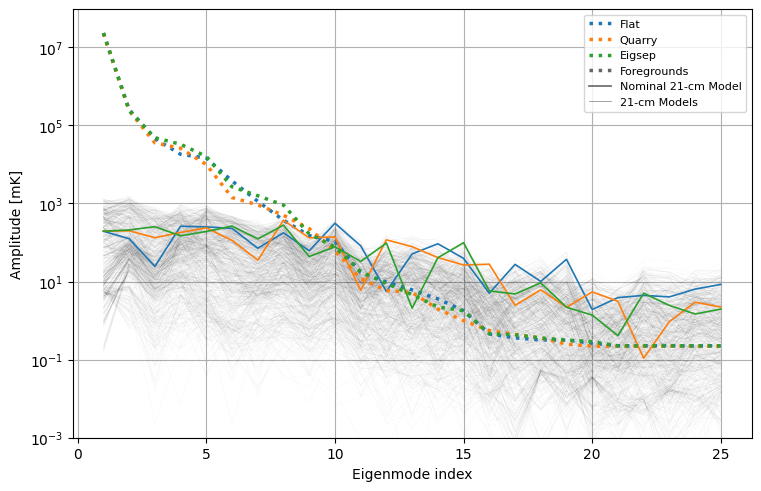

In [20]:
# fig3 alternate: model-family spaghetti instead of 16-84% bands
K_REV = 25
SUBSAMPLE = 5  # every 5th model of the family
m = np.arange(1, K_REV + 1)

fig, ax = plt.subplots(figsize=(7.5, 4.8), constrained_layout=True)
# gray family spaghetti first, so the colored curves stay on top
for c in CASES:
    V = svd[c]["V"]
    a_fam = np.abs(t21[::SUBSAMPLE] @ V) * 1e3  # [mK]
    ax.semilogy(m, a_fam[:, :K_REV].T, color="k", lw=0.3, alpha=0.04)
for c in CASES:
    s, V = svd[c]["s"], svd[c]["V"]
    fg_mode = s / np.sqrt(extract[c]["n_samp"]) * 1e3  # [mK]
    ax.semilogy(m, fg_mode[:K_REV], color=COLORS[c], lw=2.5, ls=":", label=c.capitalize())
    ax.semilogy(
        m,
        np.abs(V.T @ t21_nom)[:K_REV] * 1e3,
        color=COLORS[c],
        lw=1.2,
    )
ax.plot([], [], color="0.4", lw=2.5, ls=":", label="Foregrounds")
ax.plot([], [], color="0.4", lw=1.2, label="Nominal 21-cm Model")
ax.plot(
    [], [], color="k", lw=0.5, alpha=0.5,
    label=f"21-cm Models",
)
ax.set_ylim(1e-3, None)
ax.set_xlabel("Eigenmode index")
ax.set_ylabel("Amplitude [mK]")
#ax.set_title("Zenith pointing: foregrounds vs 21-cm signal, per eigenmode")
ax.legend(fontsize=8)
ax.grid()
plt.show()

fig.savefig("fig3_zenith_eigenbasis_spaghetti.pdf", bbox_inches="tight")

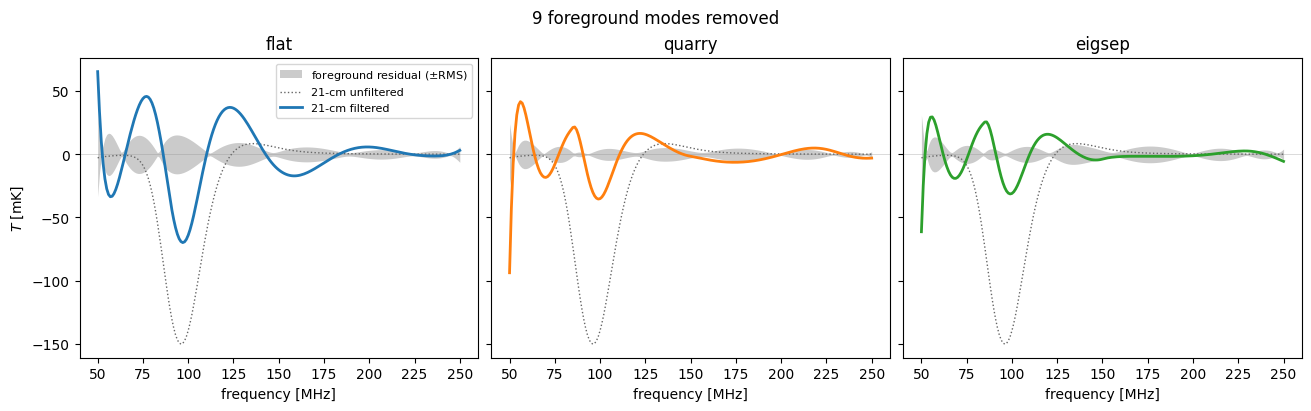

In [21]:
# fig4 alternate: foreground residual and 21-cm signal together,
# linear scale, one panel per case; same number of modes removed
# for all cases so the panels are directly comparable
N_FILT = 9
fig, axs = plt.subplots(
    1, len(CASES), figsize=(13, 4), sharex=True, sharey=True,
    constrained_layout=True,
)
for ax, c in zip(axs, CASES):
    V = svd[c]["V"]
    Xz = extract[c]["zen_sky"]

    VN = V[:, :N_FILT]
    R = Xz - (Xz @ VN) @ VN.T
    fg_spec = np.sqrt((R**2).mean(axis=0)) * 1e3  # RMS over LSTs [mK]
    t21_filt = (t21_nom - VN @ (VN.T @ t21_nom)) * 1e3

    ax.fill_between(
        freqs, -fg_spec, fg_spec, color="0.55", alpha=0.45, lw=0,
        label=r"foreground residual ($\pm$RMS)",
    )
    ax.plot(
        freqs, t21_nom * 1e3, color="0.4", lw=1, ls=":",
        label="21-cm unfiltered",
    )
    ax.plot(freqs, t21_filt, color=COLORS[c], lw=2, label="21-cm filtered")
    ax.axhline(0.0, color="0.8", lw=0.5, zorder=0)
    ax.set_title(c)
    ax.set_xlabel("frequency [MHz]")
fig.suptitle(f"{N_FILT} foreground modes removed")
axs[0].set_ylabel(r"$T$ [mK]")
axs[0].legend(fontsize=8)
plt.show()

fig.savefig("fig4_zenith_filtered_linear.pdf", bbox_inches="tight")